In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install fuzzy-c-means

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.3 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.13.0
    Uninstalling typer-0.13.0:
      Successfully uninstalled typer-0.13.0
  Attempting uninstall: tabulate
    Found existing installation: tabulate 0.9.0
    Uninstalling tabulate-0.9.0:
      Successfully uninstalled tabulate-0.9.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 1.27.0 requires tabulate>=0.9, but you have tabulate 0.8.10 which is incompatible.


n_components terbaik: 2
Silhouette Score terbaik: 0.5406340728714781


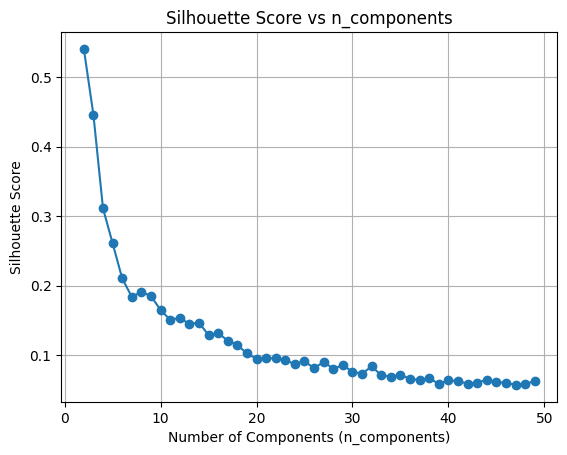

In [6]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from fcmeans import FCM
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv("/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing.csv")
texts = df['Hasil stopword']

# Preprocessing: TF-IDF
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(texts)
tfidf_array = tfidf_matrix.toarray()

# Normalisasi data
# scaler = StandardScaler()

# Loop untuk mencari n_components terbaik
best_score = -1
best_n_components = None
silhouette_scores = []

for n_components in range(2, 50):  # Coba dari 5 hingga 30 komponen
    # Reduksi dimensi
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    data_reduced = svd.fit_transform(tfidf_array)
    # data_normalized = scaler.fit_transform(data_reduced)

    # Fuzzy C-Means
    fcm = FCM(n_clusters=2, m=2.0, max_iter=1000, error=0.001)
    fcm.fit(data_reduced)
    cluster_labels = fcm.u.argmax(axis=1)

    # Hitung silhouette score
    score = silhouette_score(data_reduced, cluster_labels)
    silhouette_scores.append((n_components, score))

    # Simpan n_components dengan score terbaik
    if score > best_score:
        best_score = score
        best_n_components = n_components

# Menampilkan hasil terbaik
print(f"n_components terbaik: {best_n_components}")
print(f"Silhouette Score terbaik: {best_score}")

# Visualisasi perubahan score
import matplotlib.pyplot as plt
n_components_list, scores = zip(*silhouette_scores)
plt.plot(n_components_list, scores, marker='o')
plt.xlabel('Number of Components (n_components)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs n_components')
plt.grid(True)
plt.show()


# **mencari n-component 11-20**

n_components terbaik: 54
Silhouette Score terbaik: 0.05780643096935026


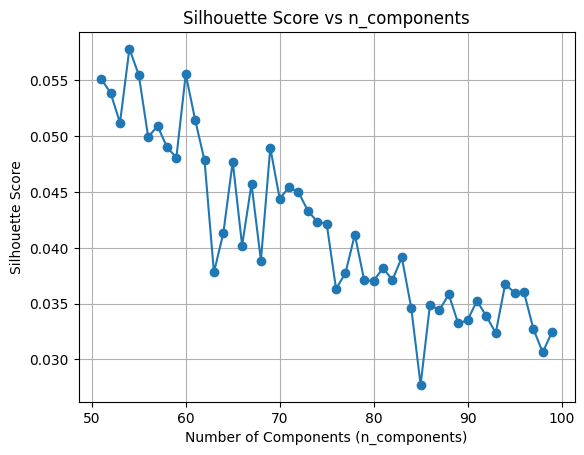

In [8]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from fcmeans import FCM
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv("/content/drive/My Drive/PPW-A/report/Tugas-PPW/hasil_preprocesing.csv")
texts = df['Hasil stopword']

# Preprocessing: TF-IDF
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(texts)
tfidf_array = tfidf_matrix.toarray()

# # Normalisasi data
# scaler = StandardScaler()

# Loop untuk mencari n_components terbaik
best_score = -1
best_n_components = None
silhouette_scores = []

for n_components in range(51, 100):  # Coba dari 5 hingga 30 komponen
    # Reduksi dimensi
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    data_reduced = svd.fit_transform(tfidf_array)
    # data_normalized = scaler.fit_transform(data_reduced)

    # Fuzzy C-Means
    fcm = FCM(n_clusters=2, m=2.0, max_iter=1000, error=0.001)
    fcm.fit(data_reduced)
    cluster_labels = fcm.u.argmax(axis=1)

    # Hitung silhouette score
    score = silhouette_score(data_reduced, cluster_labels)
    silhouette_scores.append((n_components, score))

    # Simpan n_components dengan score terbaik
    if score > best_score:
        best_score = score
        best_n_components = n_components

# Menampilkan hasil terbaik
print(f"n_components terbaik: {best_n_components}")
print(f"Silhouette Score terbaik: {best_score}")

# Visualisasi perubahan score
import matplotlib.pyplot as plt
n_components_list, scores = zip(*silhouette_scores)
plt.plot(n_components_list, scores, marker='o')
plt.xlabel('Number of Components (n_components)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs n_components')
plt.grid(True)
plt.show()


# **mencari n-componenet 21-30**

n_components terbaik: 28
Silhouette Score terbaik: 0.045412432069769075


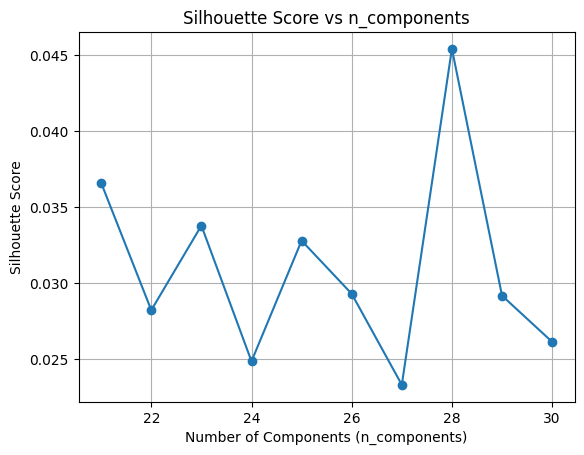

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from fcmeans import FCM
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv("/content/drive/My Drive/PPW/report/tugas_ppw/hasil_prepros.csv")
texts = df['stopword_removal']

# Preprocessing: TF-IDF
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(texts)
tfidf_array = tfidf_matrix.toarray()

# Normalisasi data
scaler = StandardScaler()

# Loop untuk mencari n_components terbaik
best_score = -1
best_n_components = None
silhouette_scores = []

for n_components in range(21, 31):  # Coba dari 5 hingga 30 komponen
    # Reduksi dimensi
    svd = TruncatedSVD(n_components=n_components, random_state=0)
    data_reduced = svd.fit_transform(tfidf_array)
    data_normalized = scaler.fit_transform(data_reduced)

    # Fuzzy C-Means
    fcm = FCM(n_clusters=2)
    fcm.fit(data_normalized)
    cluster_labels = fcm.u.argmax(axis=1)

    # Hitung silhouette score
    score = silhouette_score(data_normalized, cluster_labels)
    silhouette_scores.append((n_components, score))

    # Simpan n_components dengan score terbaik
    if score > best_score:
        best_score = score
        best_n_components = n_components

# Menampilkan hasil terbaik
print(f"n_components terbaik: {best_n_components}")
print(f"Silhouette Score terbaik: {best_score}")

# Visualisasi perubahan score
import matplotlib.pyplot as plt
n_components_list, scores = zip(*silhouette_scores)
plt.plot(n_components_list, scores, marker='o')
plt.xlabel('Number of Components (n_components)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs n_components')
plt.grid(True)
plt.show()


# **mencari n-component 181-210**

Jumlah data pada setiap cluster:
Cluster
0    91
1     9
Name: count, dtype: int64


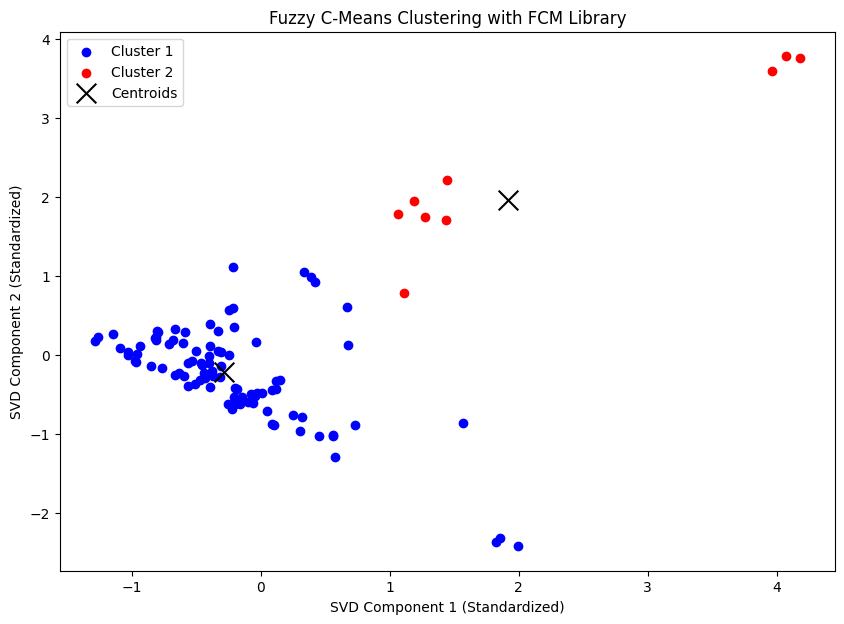

In [ ]:
from fcmeans import FCM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load data
df = pd.read_csv("/content/drive/My Drive/PPW/report/tugas_ppw/hasil_prepros.csv")
texts = df['stopword_removal']

# Preprocessing: TF-IDF
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(texts)
tfidf_array = tfidf_matrix.toarray()

# Reduksi dimensi menggunakan SVD
svd = TruncatedSVD(n_components=2, random_state=0)  # Pilih jumlah komponen terbaik
data_2d = svd.fit_transform(tfidf_array)

# Normalisasi data
scaler = StandardScaler()
data_2d_normalized = scaler.fit_transform(data_2d)

# Fuzzy C-Means Clustering
fcm = FCM(n_clusters=2)  # Tentukan jumlah klaster
fcm.fit(data_2d_normalized)

# Hasil klaster
cluster_labels = fcm.u.argmax(axis=1)  # Cluster dengan keanggotaan tertinggi
df['Cluster'] = cluster_labels

# Menampilkan jumlah data pada setiap cluster
cluster_counts = df['Cluster'].value_counts()
print("Jumlah data pada setiap cluster:")
print(cluster_counts)

# Visualisasi hasil klasterisasi
plt.figure(figsize=(10, 7))
colors = ['b', 'r']
for i in range(2):  # Sesuaikan dengan jumlah cluster
    plt.scatter(data_2d_normalized[cluster_labels == i, 0],
                data_2d_normalized[cluster_labels == i, 1],
                color=colors[i], label=f'Cluster {i+1}')

# Menampilkan pusat cluster
plt.scatter(fcm.centers[:, 0], fcm.centers[:, 1], marker='x', s=200, color='k', label='Centroids')
plt.xlabel('SVD Component 1 (Standardized)')
plt.ylabel('SVD Component 2 (Standardized)')
plt.title('Fuzzy C-Means Clustering with FCM Library')
plt.legend()
plt.show()
